There are 2 ways in smolagent to define a tool , as tools are treated as functions by llm in smolagent
1. @tool
2. class Tool

In [1]:
from smolagents import CodeAgent , InferenceClientModel , tool

model = InferenceClientModel(
    model_id="Qwen/Qwen2.5-Coder-32B-Instruct",
)

In [2]:
# Let's pretend we have a function that fetches the highest-rated catering services
@tool
def catering_service_tool(query : str) -> str:
    """
        This tool returns the highest-rated catering service in Gotham city
        Args:
            query : A search term for findng catering service
    """

    # Example list of catering services and their ratings
    services = {
        "Gotham Catering Co.": 4.9,
        "Wayne Manor Catering": 4.8,
        "Gotham City Events": 4.7,
    }

    # Find the highest rated catering service (simulating search query filtering)
    best_service = max(services, key=services.get)

    return best_service

agent = CodeAgent(
    tools = [
        catering_service_tool
    ],
    model = model
)

result = agent.run(
    "Can you give me the name of the highest-rated catering service in Gotham City?"
)

print(result)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Can you give me the name of the highest-rated catering service in Gotham City?                                  │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-Coder-32B-Instruct ────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  highest_rated_caterer = catering_service_tool(query="highest-rated catering service in Gotham City")             
  print(highest_rated_caterer)                                                                                     
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
Gotham Catering Co.

Out: None

[Step 1: Duration 3.06 seconds| Input tokens: 2,082 | Output tokens: 64]

...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 4 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer(highest_rated_caterer)                                                                              
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: Gotham Catering Co.

[Step 4: Duration 2.41 seconds| Input tokens: 9,407 | Output tokens: 356]

Gotham Catering Co.


In [3]:
from smolagents import Tool

class SuperheroPartyThemeTool(Tool):
    name = "superherp_party_theme_tool"
    description = """
    This tool suggests creative superhero-themed party ideas based on a category.
    It returns a unique party theme idea."""
    inputs = {
        "category" : {
            "type" : "string",
            "description" : "The type of superhero party (e.g., 'classic heroes', 'villain masquerade', 'futuristic Gotham')."
        }
    }
    output_type = "string"

    def forward(self , category : str):
        themes = {
            "classic heroes": "Justice League Gala: Guests come dressed as their favorite DC heroes with themed cocktails like 'The Kryptonite Punch'.",
            "villain masquerade": "Gotham Rogues' Ball: A mysterious masquerade where guests dress as classic Batman villains.",
            "futuristic Gotham": "Neo-Gotham Night: A cyberpunk-style party inspired by Batman Beyond, with neon decorations and futuristic gadgets."
        }

        return themes.get(category.lower(), "Themed party idea not found. Try 'classic heroes', 'villain masquerade', or 'futuristic Gotham'.")

party_theme_tool = SuperheroPartyThemeTool()
agent = CodeAgent(
    tools = [
        party_theme_tool
    ],
    model = model
)

# Run the agent to generate a party theme idea
result = agent.run(
    "What would be a good superhero party idea for a 'villain masquerade' theme?"
)

print(result)  # Output: "Gotham Rogues' Ball: A mysterious masquerade where guests dress as classic Batman villains."

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ What would be a good superhero party idea for a 'villain masquerade' theme?                                     │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-Coder-32B-Instruct ────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  villain_masquerade_theme = superherp_party_theme_tool(category="villain masquerade")                             
  final_answer(villain_masquerade_theme)                                                                           
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: Gotham Rogues' Ball: A mysterious masquerade where guests dress as classic Batman villains.

[Step 1: Duration 2.11 seconds| Input tokens: 2,118 | Output tokens: 73]

Gotham Rogues' Ball: A mysterious masquerade where guests dress as classic Batman villains.


smolagents comes with a set of pre-built tools that can be directly injected into your agent. The default toolbox includes:

- PythonInterpreterTool
- FinalAnswerTool
- UserInputTool
- DuckDuckGoSearchTool
- GoogleSearchTool
- VisitWebpageTool

One of the most powerful features of smolagents is its ability to share custom tools on the Hub and seamlessly integrate tools created by the community. This includes connecting with HF Spaces and LangChain tools, significantly enhancing Alfred’s ability to orchestrate an unforgettable party at Wayne Manor. 🎭

In [4]:
# This is how you can share your tool to the HUB

# party_theme_tool.push_to_hub("{your_username}/party_theme_tool", token="<YOUR_HUGGINGFACEHUB_API_TOKEN>")

You can easily import tools created by other users using the `load_tool()` function. For example, Alfred might want to generate a promotional image for the party using AI. Instead of building a tool from scratch, he can leverage a predefined one from the community:

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Generate an image of a luxurious superhero-themed party at Wayne Manor with made-up superheros.                 │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-Coder-32B-Instruct ────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  prompt = "A luxurious superhero-themed party at Wayne Manor with made-up superheros. High-res, photorealistic,   
  detailed, colorful, featuring opulent decorations, sophisticated party guests, and iconic elements of Wayne      
  Manor."                                                                                                          
  image = image_generator(prompt=prompt)                                                                           
  final_answer(image)                                                                                              
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024 at 0x7C481BE3C440>

[Step 1: Duration 6.93 seconds| Input tokens: 2,111 | Output tokens: 90]

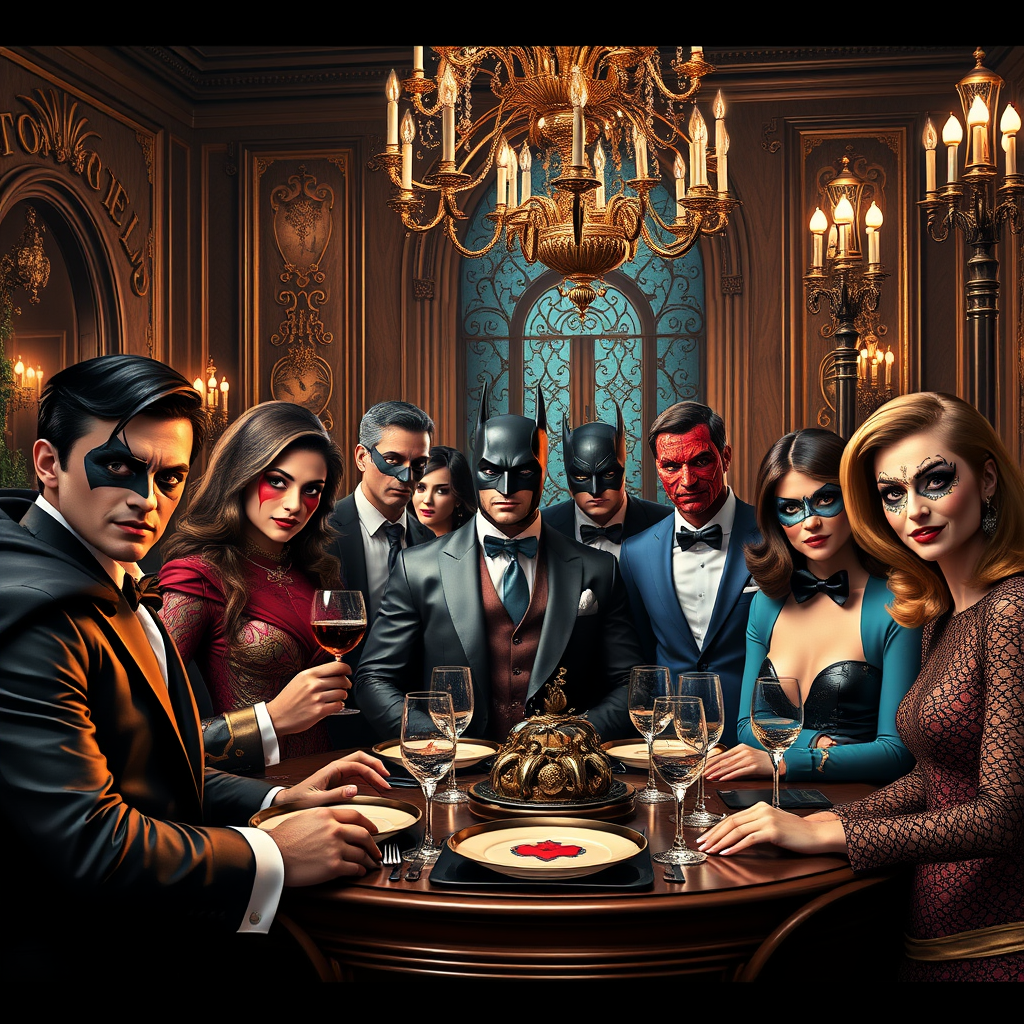

In [5]:
from smolagents import load_tool

image_generation_tool = load_tool(
    "m-ric/text-to-image",
    trust_remote_code = True
)

agent = CodeAgent(
    tools = [
        image_generation_tool
    ],
    model = model
)

agent.run("Generate an image of a luxurious superhero-themed party at Wayne Manor with made-up superheros.")

You can also import a HF Space as a tool using `Tool.from_space()`. This opens up possibilities for integrating with thousands of spaces from the community for tasks from image generation to data analysis.

The tool will connect with the spaces Gradio backend using the `gradio_client`, so make sure to install it via `pip` if you don’t have it already.

For the party, Alfred can use an existing HF Space for the generation of the AI-generated image to be used in the announcement (instead of the pre-built tool we mentioned before). Let’s build it!

In [6]:
# There is some HF token related issue over here . But code is working fine.

import os
from google.colab import userdata
from smolagents import Tool, CodeAgent

HF_TOKEN = userdata.get("HF_TOKEN")

print("HF token loaded:", bool(HF_TOKEN))

image_generation_tool = Tool.from_space(
    "black-forest-labs/FLUX.1-schnell",
    name="image_generator",
    description="Generate an image from a prompt",
    token=HF_TOKEN
)

agent = CodeAgent(
    tools=[image_generation_tool],
    model=model
)

agent.run(
    "Improve this prompt, then generate an image of it.",
    additional_args={
        "user_prompt": (
            "A grand superhero-themed party at Wayne Manor, "
            "with Alfred overseeing a luxurious gala"
        )
    }
)

HF token loaded: True
Loaded as API: https://black-forest-labs-flux-1-schnell.hf.space ✔


/usr/local/lib/python3.13/dist-packages/smolagents/tools.py:666: UserWarning: Since `api_name` was not defined, it was automatically set to the first available API: `/infer`.
  warnings.warn(


╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Improve this prompt, then generate an image of it.                                                              │
│ You have been provided with these additional arguments, that you can access directly using the keys as          │
│ variables:                                                                                                      │
│ {'user_prompt': 'A grand superhero-themed party at Wayne Manor, with Alfred overseeing a luxurious gala'}.      │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-Coder-32B-Instruct ────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Error in generating model output:
Client error '402 Payment Required' for url 'https://router.huggingface.co/v1/chat/completions' (Request ID: 
Root=1-6abb59f7-36479f994c6a6a301e0813f1;0a876c8a-7ddf-4d6f-87f0-dd703f5366ec)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/402

You have depleted your monthly included credits. Purchase pre-paid credits to continue using Inference Providers. 
Alternatively, subscribe to PRO to get 20x more included usage.

[Step 1: Duration 0.11 seconds]

AgentGenerationError: Error in generating model output:
Client error '402 Payment Required' for url 'https://router.huggingface.co/v1/chat/completions' (Request ID: Root=1-6abb59f7-36479f994c6a6a301e0813f1;0a876c8a-7ddf-4d6f-87f0-dd703f5366ec)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/402

You have depleted your monthly included credits. Purchase pre-paid credits to continue using Inference Providers. Alternatively, subscribe to PRO to get 20x more included usage.

### Using langchain tools
After installing the langchain integration, make sure to set your SerpAPI key. This is required for search-based tools such as SerpAPITool:

In [7]:
!pip install -U langchain-community

In [8]:
SERPAPI_API_KEY = userdata.get("SERPAPI_API_KEY")

# from langchain.agents import load_tools

# search_tool = Tool.from_langchain(
#     load_tools(
#         ["serpapi"],
#         serp_api_key = SERPAPI_API_KEY
#     )[0]
# )

# New imports for Langchain's SerpAPI tool
from langchain_community.utilities import SerpAPIWrapper
from langchain.tools import Tool as LangchainTool # Renaming to avoid conflict with smolagents.Tool
from smolagents import Tool, CodeAgent # Ensure smolagents classes are available

# Instead of load_tools, we directly create the SerpAPI tool
serpapi_wrapper = SerpAPIWrapper(serpapi_api_key=SERPAPI_API_KEY)

# Create a Langchain Tool object
# The name and description are important for the agent to understand its purpose
langchain_serpapi_tool = LangchainTool(
    name="SerpAPI Search",
    description="Useful for when you need to answer questions about current events or perform web searches.",
    func=serpapi_wrapper.run
)

# Wrap the Langchain tool with smolagents.Tool.from_langchain
search_tool = Tool.from_langchain(langchain_serpapi_tool)

agent = CodeAgent(
    tools = [
        search_tool
    ],
    model = model
)

agent.run("Search for luxury entertainment ideas for a superhero-themed event, such as live performances and interactive experiences.")

/tmp/ipykernel_19300/3301446760.py:13: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import SerpAPIWrapper


ImportError: cannot import name 'Tool' from 'langchain.tools' (/usr/local/lib/python3.13/dist-packages/langchain/tools/__init__.py)

smolagents also allows importing tools from the hundreds of MCP servers available on glama.ai or smithery.ai.

In [9]:
!pip install -U "smolagents[mcp]"

In [10]:
from mcp import StdioServerParameters
from smolagents import ToolCollection

server_parameters = StdioServerParameters(
    command = "uvx",
    args = ["--quiet" , "pubmedmcp@0.1.3"],
    env = {"UV_PYTHON": "3.12", **os.environ},
)

with ToolCollection.from_mcp(server_parameters , trust_remote_code = True) as tool_collection:
    agent = CodeAgent(tools=[*tool_collection.tools], model=model, add_base_tools=True)
    agent.run("Please find a remedy for hangover.")

/usr/lib/python3.13/contextlib.py:141: FutureWarning: Parameter 'structured_output' was not specified. Currently it defaults to False, but in version 1.25, the default will change to True. To suppress this warning, explicitly set structured_output=True (new behavior) or structured_output=False (legacy behavior). See documentation at https://huggingface.co/docs/smolagents/tutorials/tools#structured-output-and-output-schema-support for more details.
  return next(self.gen)


ImportError: Please install 'mcp' extra to use ToolCollection.from_mcp: `pip install 'smolagents[mcp]'`.